## 1. Load data from Supabase

In [1]:
from sqlalchemy import create_engine
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

host = os.getenv("SUPABASE_HOST")
user = os.getenv("SUPABASE_USER")
password = os.getenv("SUPABASE_PASSWORD")

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:6543/postgres")

query = """
    SELECT
        a.activity_name, a.start_date, a.activity_type,
        a.distance, a.duration, a.elevation,
        a.max_speed, a.avg_speed, a.avg_heartrate,
        a.suffer_score, a.avg_watts, a.kilojoules,
        a.start_lat, a.start_lng, a.end_lat, a.end_lng
    FROM activities a
    JOIN athletes ath ON a.athlete_id = ath.id
    ORDER BY a.start_date DESC
"""

df = pd.read_sql(query, engine)
df["start_date"] = pd.to_datetime(df["start_date"])

splits_query = """
    SELECT
        s.id AS split_id,
        s.activity_id,
        s.split_number,
        s.distance_km,
        s.elapsed_time_s,
        s.moving_time_s,
        s.elevation_diff_m,
        s.avg_speed_kmh,
        s.avg_heartrate,
        s.pace_zone,
        a.activity_name,
        a.start_date,
        a.activity_type
    FROM splits s
    JOIN activities a ON s.activity_id = a.id
    ORDER BY a.start_date DESC, s.split_number ASC
"""

df_splits = pd.read_sql(splits_query, engine)
df_splits["start_date"] = pd.to_datetime(df_splits["start_date"])

In [5]:
## Check df variables

import json
print(df)

                             activity_name          start_date activity_type  \
0    Interval Training: 8 X 40 sec 3:30/km 2026-07-28 17:32:10           Run   
1                                 Base Run 2026-07-27 17:09:40           Run   
2                                 Long Run 2026-07-26 14:23:46           Run   
3                             Rope Jumping 2026-07-25 10:46:24       Workout   
4                                 Base Run 2026-07-24 11:25:08           Run   
..                                     ...                 ...           ...   
344                          Afternoon Run 2021-10-05 17:07:34           Run   
345                          Afternoon Run 2021-10-03 16:11:24           Run   
346                              Lunch Run 2021-09-28 12:42:38           Run   
347                            Morning Run 2021-09-25 09:04:20           Run   
348                            Evening Run 2021-09-22 18:02:29           Run   

     distance   duration  elevation  ma

## 2. Visualize activity results
Plot various metrics from the Strava activities, such as distance, duration, elevation gain, and average speed over time.

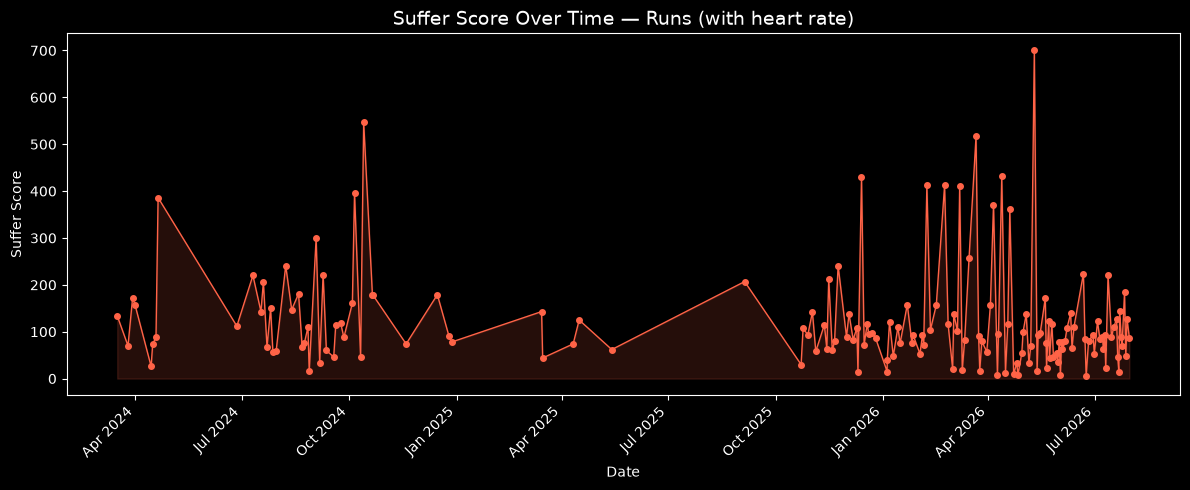

In [2]:
## VISUALIZE SUFFER SCORE ALL TIME

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

runs = (df[(df["activity_type"] == "Run")]
        .dropna(subset=["suffer_score", "avg_heartrate"])
        .sort_values("start_date"))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(runs["start_date"], runs["suffer_score"], marker="o", linewidth=1, markersize=4, color="tomato")
ax.fill_between(runs["start_date"], runs["suffer_score"], alpha=0.15, color="tomato")

ax.set_title("Suffer Score Over Time — Runs (with heart rate)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Suffer Score")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplcursors

runs = (df[(df["activity_type"] == "Run")]
        .dropna(subset=["distance"])
        .sort_values("start_date"))

fig, ax = plt.subplots(figsize=(12, 4))
line, = ax.plot(runs["start_date"], runs["distance"], marker="o", linewidth=1, markersize=4, color="steelblue")
ax.fill_between(runs["start_date"], runs["distance"], alpha=0.15, color="steelblue")

ax.set_title("Distance Run Over Time", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Distance (km)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

cursor = mplcursors.cursor(line, hover=False)

@cursor.connect("add")
def on_add(sel):
    idx = sel.index
    row = runs.iloc[idx]
    sel.annotation.set_text(
        f"{row['start_date'].strftime('%d %b %Y')}\n"
        f"Distance: {row['distance']:.1f} km\n"
        f"Suffer Score: {row.get('suffer_score', 'N/A')}"
    )

RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [4]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplcursors
import pandas as pd

runs = (df[df["activity_type"] == "Run"]
        .dropna(subset=["distance"])
        .sort_values("start_date"))

marathon1 = runs[(runs["start_date"] >= "2024-06-01") & (runs["start_date"] < "2024-10-31")]
marathon2 = runs[(runs["start_date"] >= "2025-10-10") & (runs["start_date"] < "2026-05-31")]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

cursors = []

for ax, data, title, color in [
    (ax1, marathon1, "Eindhoven Marathon - Training", "steelblue"),
    (ax2, marathon2, "Copenhagen Marathon - Training", "gold"),
]:
    line, = ax.plot(data["start_date"], data["distance"], marker="o", linewidth=1, markersize=4, color=color)
    ax.fill_between(data["start_date"], data["distance"], alpha=0.15, color=color)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel("Distance (km)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    cursor = mplcursors.cursor(line, hover=False)
    cursors.append(cursor)
    prev_sel = [None]

    @cursor.connect("add")
    def on_add(sel, d=data, p=prev_sel):
        if p[0] is not None:
            p[0].annotation.set_visible(False)
        p[0] = sel
        row = d.iloc[sel.index]
        sel.annotation.set_text(
            f"{row['start_date'].strftime('%d %b %Y')}\n"
            f"Distance: {row['distance']:.1f} km\n"
            f"Suffer Score: {row.get('suffer_score', 'N/A')}"
        )

plt.tight_layout()
plt.show()

RuntimeError: 'widget' is not a recognised GUI loop or backend name